In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker
import math
import pandas as pd
import os
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# ----- SET GLOBAL MATPLOTLIB PARAMS -----

dpi = 300

lrgtxt = 11
medtxt = 9
smltxt = 7

plt.rcParams['xtick.labelsize']=smltxt
plt.rcParams['ytick.labelsize']=smltxt

plt.rcParams['axes.titlesize']=lrgtxt
plt.rcParams['axes.labelsize']=medtxt
plt.rcParams["axes.titlepad"]=12
plt.rcParams['axes.linewidth']=1
plt.rcParams["axes.spines.right"]=False
plt.rcParams["axes.spines.top"]=False

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['savefig.dpi'] = dpi
plt.rcParams['figure.dpi']= dpi
plt.rcParams['figure.constrained_layout.use'] = True

plt.rcParams['savefig.transparent'] = True

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    # [0.34901962, 0.35686275, 0.49019608],
    [0.19140625, 0.1953125, 0.265625],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# whisker dimensions
whiskspacer = 0.15
whiskpos = -whiskspacer

# plotting parameters
medlw = 1.5 # median linewidth
boxalpha = 0.5 # transparency for boxplot face color
caps = False # don't put caps on the error bars
bwidth = 0.9 # box width
ppad = 0.0085*2 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket
dotsz = 5

# stats parameters
palpha = 0.05

# programatically set positions
dotdist = 0.15
errdist = 0.15
psdist = 1
gtdist = 1.5
start = 0

# set labels
xlab = ''
ylab = 'percent of assay'

# stats display parameters
pvpct = 0.2

# output directory for figure files
# outdir = 'M:\\scn2a-paper-GWJSNH\\manuscript_v2\\figure_panels'
outdir = 'C:\\Users\\nhogl\\Documents\\Manoli Lab\\2026_scn2a_manuscript\\figure_panels'

# save figures?
savefigs = False

# print stats?
printstats = True

In [3]:
# ----- DEFINE FUNCTIONS -----

def decide_pval_text(pval,palpha):

    if palpha<pval<palpha+0.015:
        ptxt = f'p = {pval:.2f}'
    elif pval>palpha:
        ptxt = 'n.s.'
    elif palpha/50<pval<palpha:
        ptxt='*'
    elif palpha/500<pval<palpha/50:
        ptxt ='**'
    elif palpha/5000<pval<palpha/500:
        ptxt = '***'
    else:
        ptxt = '****'
    
    return ptxt

def add_pair_to_plot_box(df,key,grp1,grp2,statkey,ax,col1,col2,startx,dotdist,errdist,psdist,whiskpos,ptxt,hatch,pdf,ckey1,ckey2,lcol):

    # -- GROUP 1 --
    tdf = df[df[key]==grp1].copy().reset_index(drop=True)
    tcol=col1

    max1 = np.max(tdf[statkey])
    min1 = np.min(tdf[statkey])
    
    # plot group 1 dots
    ax.plot(np.zeros(tdf.shape[0])+startx+dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha = 1)
    
    # plot group 1 boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)

    bplot = ax.boxplot(tdf[statkey],positions=[startx],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[startx+whiskpos],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)

    # -- GROUP 2 --    
    tdf = df[df[key]==grp2].copy().reset_index(drop=True)
    tcol=col2

    max2 = np.max(tdf[statkey])
    min2 = np.min(tdf[statkey])
    
    # plot stranger dots
    ax.plot(np.zeros(tdf.shape[0])+startx+psdist-dotdist, tdf[statkey], 'o', markerfacecolor=tcol,markeredgecolor='k',zorder=4, ms=5, mew=1, alpha=1)

    # plot stranger boxplot
    boxprops = dict(linewidth=1, facecolor=tcol+[0.5],edgecolor=tcol)
    medianprops = dict(linewidth=medlw, color=tcol)
    whiskprops = dict(linewidth=0, color=tcol,alpha=boxalpha)
    bplot = ax.boxplot(tdf[statkey],positions=[startx+psdist],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False)
    
    whiskprops = dict(linewidth=1, color=tcol)
    medianprops = dict(linewidth=0, color=None)
    ax.boxplot(tdf[statkey],positions=[(startx+psdist-whiskpos)],showcaps=caps,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,showfliers=False,showbox=False,medianprops=medianprops)
    for box in bplot['boxes']:
        box.set(hatch=hatch,fill=True)

    # plot pair lines
    for idx in pdf.index: ax.plot([startx+dotdist,startx+psdist-dotdist], pdf.loc[idx,[ckey1,ckey2]], 
                                 color = lcol, linewidth = 1, linestyle = '-', zorder=3)

    return np.min([min1,min2]), np.max([max1,max2])

def make_assay_homecage_dotbox_plots(fdat,assays,bstr,savefigs,printstats,lbls,assaydurs,hatch):
    # organize and sum total behavior time
    sums = fdat.groupby(by=['pair_tag','GT','assay']).duration.sum().reset_index()
    dfs = []
    for assay,assaydur in zip(assays,assaydurs):
        tsums = sums[sums['assay']==assay].copy().reset_index(drop=True)
        tsums['fraction']=tsums['duration']/assaydur*100
        dfs.append(tsums)
    sums = pd.concat(dfs)

    inter = np.intersect1d(dfs[0].pair_tag,dfs[1].pair_tag) # find pairs that are in both assay datasets
    df0 = dfs[0]
    interGT = df0[df0.pair_tag.isin(inter)]['GT'].copy().reset_index(drop=True)
    frac0 = df0[df0.pair_tag.isin(inter)]['fraction'].copy().reset_index(drop=True)
    frac1 = dfs[1][dfs[1].pair_tag.isin(inter)]['fraction'].copy().reset_index(drop=True)
    lab0 = f'{assays[0]}'
    lab1 = f'{assays[1]}'
    d = {'pair_tag':inter, 'GT':interGT, lab0:frac0, lab1:frac1}
    paired = pd.DataFrame(d)
    paired['diff'] = paired[lab1]-paired[lab0]

    # sums = paired
    
    # keep track of details across multiple plots
    # axes = []
    maxes = []
    mins = []
    ptxts = []
    # figs = []
    # fnames = []
    px1s = []

    # make figure
    figsz = (2.5,2) # total size of figure
    fig, ax = plt.subplots(figsize=figsz)
    # axes.append(ax)
    # figs.append(fig)
    
    # do a loop over sexes to make sure they have the same axis parameters
    for gt in ['WT','Het']:

        if gt=='WT':
            col = mcols[0]
            xstart = start
        else:
            col = mcols[1]
            xstart = start+psdist+gtdist

        px1s.append(xstart)
    
        # fname = f'boxDotPlot_{assays[0]}-vs-{assays[1]}_{bstr}{sex}_{gt}.svg' # generate file name for output plot
        # print(fname)
        # fnames.append(fname)
    
        # filter to given gt
        fsums = sums[sums['GT']==gt].copy().reset_index(drop=True)
        fpaired = paired[paired['GT']==gt].copy().reset_index(drop=True)
    
        # -- stats --

        isnorms = []

        # calculate assay differences between pairs

        # normality test on constant-added, log transformed data
        constant = 1.0001-np.min(fpaired['diff'])
        shapres = scipy.stats.shapiro(np.log(fpaired['diff']+constant))
        isnormal = shapres.pvalue>palpha
        isnormal = False # !! hardcoded in because only the WT intro vs reunion comparison is WT, so just use non parametric tests
        isnorms.append(isnormal)
        normal_method = 'Shapiro-Wilk test'
        print(f'Normality test results for {gt} {assay}: {isnormal} by {normal_method}, p = {shapres.pvalue}')

        if isnormal:
            statres = scipy.stats.ttest_rel(np.log(fpaired[lab1]+constant),np.log(fpaired[lab0]+constant))
        else:
            statres = scipy.stats.wilcoxon(fpaired['diff'])

        fsums = fsums[fsums['pair_tag'].isin(inter)].copy().reset_index(drop=True)



        # !! ----- TREAT EACH ASSAY AS AN INDEPENDENT SAMPLE -----
        # isnorms = []
        # for assay in assays:
        #     # isnormal,p_values,normal_method = testNormal(np.log(fsums[fsums['GT']==gt]['duration']))
        #     shapres = scipy.stats.shapiro(np.log(fsums[fsums['assay']==assay]['duration']))
        #     p_values = shapres.pvalue
        #     isnormal = p_values>palpha
        #     normal_method = 'Shapiro-Wilk test'
        #     isnorms.append(isnormal)
        #     print(f'Normality test results for {gt} {assay}: {isnormal} by {normal_method}, p = {p_values}')
        # # check whether normal distribution holds
        # if all(isnorms):
        #     # check for equal variance
        #     bartres = scipy.stats.bartlett(np.log(fsums[fsums['assay']==assays[0]]['duration']),np.log(fsums[fsums['assay']==assays[1]]['duration']))
        #     eqvar = bartres.pvalue>0.05
        #     # run ttest on log transformed data
        #     statres = scipy.stats.ttest_ind(np.log(fsums[fsums['assay']==assays[0]]['duration']),np.log(fsums[fsums['assay']==assays[1]]['duration']),equal_var=eqvar)
        # else:
        #     statres = scipy.stats.mannwhitneyu(np.log(fsums[fsums['assay']==assays[0]]['duration']),np.log(fsums[fsums['assay']==assays[1]]['duration']))
    
        if printstats:
            print(statres) 
        pval = statres.pvalue
        ptxt = decide_pval_text(pval,palpha)
        ptxts.append(ptxt)
    
        # make figure
        # figsz = (1.25,2) # total size of figure
        # fig, ax = plt.subplots(figsize=figsz)
        # axes.append(ax)
        # figs.append(fig)
    
        # make plot
        mn,mx = add_pair_to_plot_box(fsums,'assay',assays[0],assays[1],'fraction',ax,col,col,xstart,dotdist,errdist,psdist,whiskpos,ptxt,hatch,
                                    paired[paired['GT']==gt].copy().reset_index(drop=True),lab0,lab1,'k')
        maxes.append(mx)
        mins.append(mn)
        # fig.text(0.64,-0.065,'Scn2a',ha='center',size=lrgtxt)
        # plt.text(0.5,-0.065,'Scn2a',ha='center',size=lrgtxt)

    
    # for ax,ptxt,fig,fname in zip(axes,ptxts,figs,fnames):
    ax.set_yscale('log')
    
    # calculations for scaling min, max, and pval stuff
    tmx = np.max(maxes)
    tmn = np.min(mins)
    axmin = tmn-0.25*tmn
    axmax = 1.7*tmx
    ax.set_ylim([axmin,axmax])
    
    # display statistical test results
    axrange = axmax-axmin
    ppad = axrange*pvpct
    y, h = tmx + ppad, ppad
    for ptxt,px1 in zip(ptxts,px1s):
        # px1 = start
        px2 = px1+psdist
        ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c='k')
        # make height pad factor to pull test bracket up
        ax.text((px1+px2)*.5, y+h+0.3*h, ptxt, ha='center', va='bottom', color='k',size=medtxt)
    
    # labeling
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([start,start+psdist,start+psdist+gtdist,start+psdist+gtdist+psdist],labels=lbls*2,fontsize=medtxt)
    ax.get_yaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
    ax.get_yaxis().set_minor_formatter(matplotlib.ticker.NullFormatter())
    labels = []
    for tick in ax.get_yticks():
        if tick>=1:
            label = f'{int(tick)}'
        else:
            label = f'{tick: .1f}'
        labels.append(label)
    ax.set_yticklabels(labels)
    ax.tick_params(axis='x', which='both',length=0)
    ax.set_xlabel(xlab,)
    ax.set_ylabel(ylab)
    ax.set_title(bstr)

    if savefigs:
        fig.savefig(os.path.join(outdir,fname),bbox_inches='tight')

In [4]:
# ----- LOAD DATA -----
data_orig = pd.read_csv(os.path.join('..','all_annotations.csv')).drop(labels=['Unnamed: 0','id'],axis=1)

In [5]:
data_orig.head()

,start_time,stop_time,behavior,duration,atype,pair_tag,sex,GT,color,assay,pair_num
0,0.001,0.498,No interaction,0.497,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
1,0.499,3.555,Investigate,3.056,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
2,3.556,5.411,Sniff,1.855,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
3,5.412,5.976,No interaction,0.564,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1
4,5.977,7.720,Sniff,1.743,STATE,Pair15,F,Het,[245. 201. 39.],aggression,1


In [7]:
np.unique(data_orig.assay)

array(['PPT', 'aggression', 'introduction', 'reunion', 'timedMating'],
      dtype=object)

In [6]:
# ----- FILTER DATA -----

# filter to males
sex = 'M'
data = data_orig[data_orig.sex==sex].copy().reset_index(drop=True)

Normality test results for WT reunion: False by Shapiro-Wilk test, p = 0.40223036408212276
WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00048828125))
Normality test results for Het reunion: False by Shapiro-Wilk test, p = 0.012696397203125038
WilcoxonResult(statistic=np.float64(1.0), pvalue=np.float64(0.000244140625))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_20300\2627984233.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


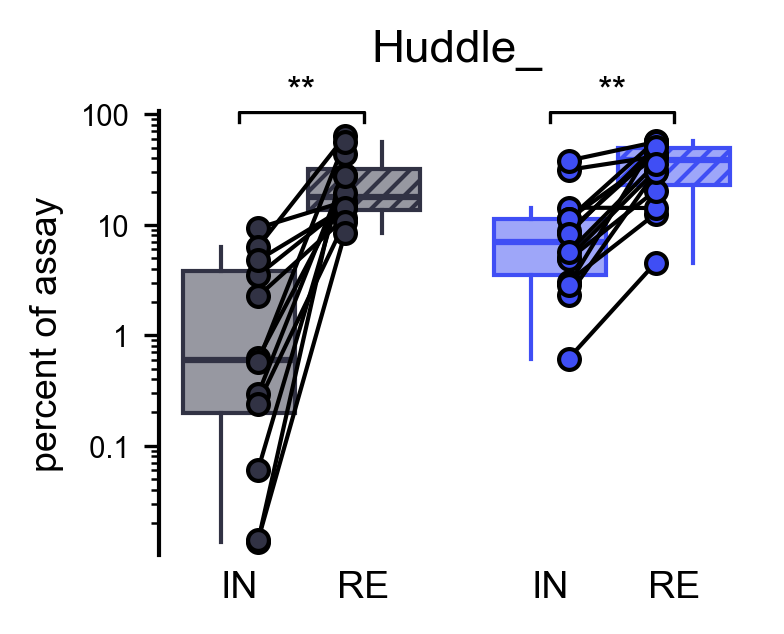

In [119]:
# ----- COMPARE HUDDLES BETWEEN INTRO AND REUNION -----

behavs = ['Investigate','Sniff','Huddle']
assays = ['introduction','reunion']
assaydur = 1800
hatch='/////'
lbls = ['IN','RE']

# filter to relevant single behavior
i = 2
blist = [behavs[i]]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_assay_homecage_dotbox_plots(fdat,assays,bstr,savefigs,printstats,lbls,[assaydur]*2,hatch)

Normality test results for WT aggression: False by Shapiro-Wilk test, p = 0.00011998426703254042
WilcoxonResult(statistic=np.float64(28.0), pvalue=np.float64(0.423828125))
Normality test results for Het aggression: False by Shapiro-Wilk test, p = 9.13703030824452e-05
WilcoxonResult(statistic=np.float64(34.0), pvalue=np.float64(0.267578125))


C:\Users\nhogl\AppData\Local\Temp\ipykernel_20300\2627984233.py:231: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


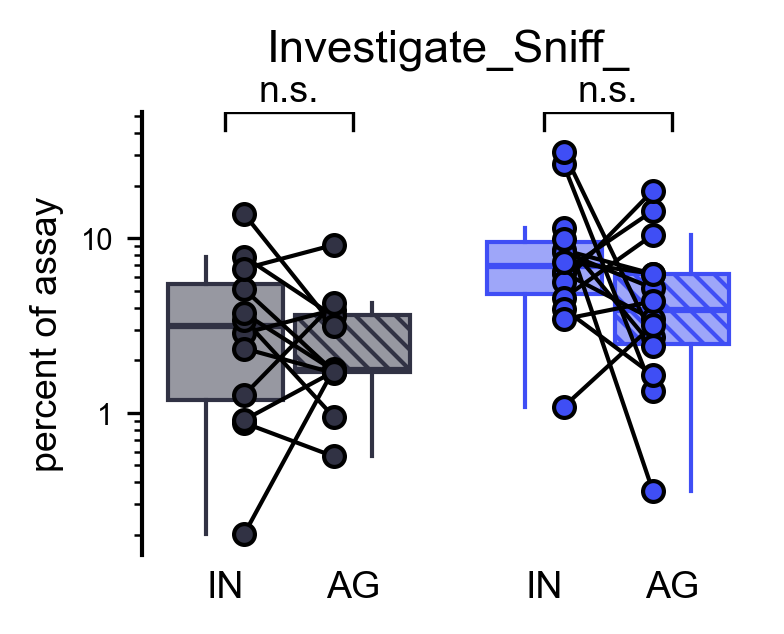

In [120]:
# ----- COMPARE INVESTIGATION BETWEEN INTRO AND AGGRESSION -----

behavs = ['Investigate','Sniff','Huddle']
assays = ['introduction','aggression']
assaydur = 1800
hatch='\\\\\\\\\\'
lbls = ['IN','AG']

# filter to relevant single behavior
blist = behavs[0:2]
fdat = data[data.behavior.isin(blist)].copy().reset_index(drop=True)
bstr = ''
for bhv in blist:
    bstr+=f'{bhv}_'

make_assay_homecage_dotbox_plots(fdat,assays,bstr,savefigs,printstats,lbls,[1800,1200],hatch)

Text(0, 0.5, 'affiliative behaviors')

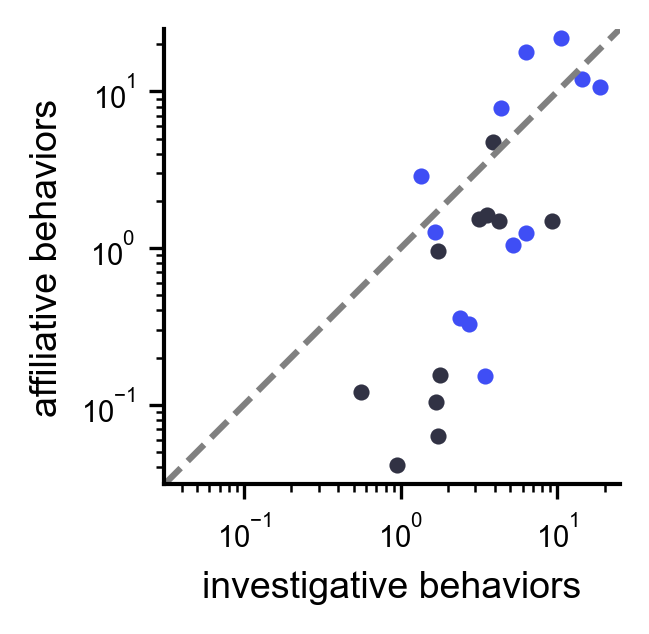

In [35]:
# ----- PLOT RELATIONSHIP OF INVESTIGATION TIME AND HUDDLE TIME IN AGGRESSION ASSAY -----

behavs = ['Investigate','Sniff','Huddle']
assay = 'aggression'
assaydur = 1200

# filter to relevant behaviors
blist = behavs[0:2]
tdat = data[data.assay==assay].copy().reset_index(drop=True)
idat = tdat[tdat.behavior.isin(blist)].copy().reset_index(drop=True)
hdat = tdat[tdat.behavior=='Huddle'].copy().reset_index(drop=True)

isums = idat.groupby(by=['pair_tag','GT']).duration.sum().reset_index()
hsums = hdat.groupby(by=['pair_tag','GT']).duration.sum().reset_index()

df = isums.join(hsums.set_index('pair_tag').drop(labels=['GT'],axis=1),on='pair_tag',how='outer',lsuffix='_investigate',rsuffix='_huddle').fillna(0)
df['investigate_pct'] = 100*df.duration_investigate/assaydur
df['huddle_pct'] = 100*df.duration_huddle/assaydur

dotsz = 15
dlw = 0

# separate WT and het
wt = df[df.GT=='WT'].copy().reset_index(drop=True)
ht = df[df.GT=='Het'].copy().reset_index(drop=True)

# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

# scatter plot WT
ax.scatter(wt.investigate_pct,wt.huddle_pct,s=dotsz,c=[mcols[0]],edgecolors='k',linewidths=dlw)

# scatter plot het
ax.scatter(ht.investigate_pct,ht.huddle_pct,s=dotsz,c=[mcols[1]],edgecolors='k',linewidths=dlw)

# manage axis
ax.set_xscale('log')
ax.set_yscale('log')
alldat = pd.concat([wt.investigate_pct,wt.huddle_pct,ht.investigate_pct,ht.huddle_pct])
alldat = alldat[alldat>0]
minval = np.min(alldat)
minax = minval-0.25*minval
maxax = 25
ax.plot([minax, maxax],[minax, maxax],'--',color=[0.5,0.5,0.5])
ax.set_xlim([minax,maxax])
ax.set_ylim([minax,maxax])
ax.set_aspect('equal')
ax.set_xlabel('investigative behaviors')
ax.set_ylabel('affiliative behaviors')

Text(0, 0.5, 'affiliative behaviors')

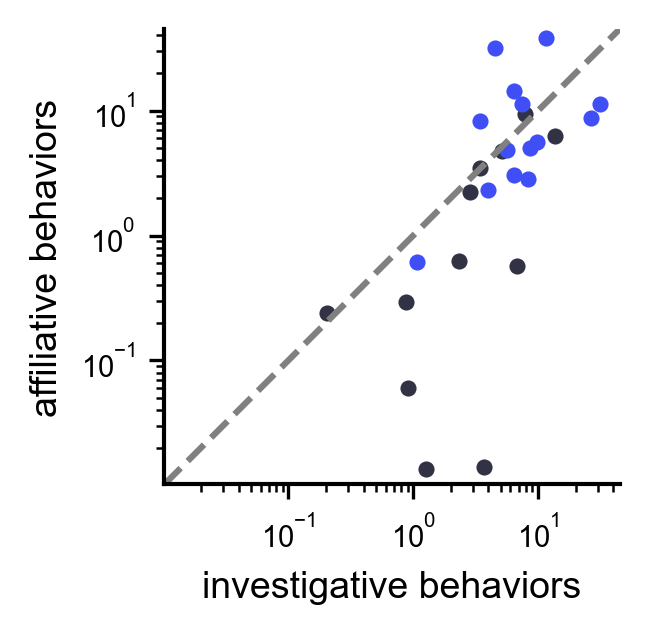

In [41]:
# ----- PLOT RELATIONSHIP OF INVESTIGATION TIME AND HUDDLE TIME IN INTRODUCTION ASSAY -----

behavs = ['Investigate','Sniff','Huddle']
assay = 'introduction'
assaydur = 1800

# filter to relevant behaviors
blist = behavs[0:2]
tdat = data[data.assay==assay].copy().reset_index(drop=True)
idat = tdat[tdat.behavior.isin(blist)].copy().reset_index(drop=True)
hdat = tdat[tdat.behavior=='Huddle'].copy().reset_index(drop=True)

isums = idat.groupby(by=['pair_tag','GT']).duration.sum().reset_index()
hsums = hdat.groupby(by=['pair_tag','GT']).duration.sum().reset_index()

df = isums.join(hsums.set_index('pair_tag').drop(labels=['GT'],axis=1),on='pair_tag',how='outer',lsuffix='_investigate',rsuffix='_huddle').fillna(0)
df['investigate_pct'] = 100*df.duration_investigate/assaydur
df['huddle_pct'] = 100*df.duration_huddle/assaydur

dotsz = 15
dlw = 0

# separate WT and het
wt = df[df.GT=='WT'].copy().reset_index(drop=True)
ht = df[df.GT=='Het'].copy().reset_index(drop=True)

# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

# scatter plot WT
ax.scatter(wt.investigate_pct,wt.huddle_pct,s=dotsz,c=[mcols[0]],edgecolors='k',linewidths=dlw)

# scatter plot het
ax.scatter(ht.investigate_pct,ht.huddle_pct,s=dotsz,c=[mcols[1]],edgecolors='k',linewidths=dlw)

# manage axis
ax.set_xscale('log')
ax.set_yscale('log')
alldat = pd.concat([wt.investigate_pct,wt.huddle_pct,ht.investigate_pct,ht.huddle_pct])
alldat = alldat[alldat>0]
minval = np.min(alldat)
minax = minval-0.25*minval
maxax = 45
ax.plot([minax, maxax],[minax, maxax],'--',color=[0.5,0.5,0.5])
ax.set_xlim([minax,maxax])
ax.set_ylim([minax,maxax])
ax.set_aspect('equal')
ax.set_xlabel('investigative behaviors')
ax.set_ylabel('affiliative behaviors')

In [37]:
df

,pair_tag,GT,duration_investigate,duration_huddle,investigate_pct,huddle_pct
0,Pair17,Het,114.696,55.197,6.372000,3.066500
1,Pair18,WT,51.562,40.503,2.864556,2.250167
2,Pair19,WT,141.159,168.212,7.842167,9.345111
3,Pair24,Het,116.253,257.267,6.458500,14.292611
4,Pair25,Het,154.578,90.716,8.587667,5.039778
5,Pair26,Het,477.833,157.679,26.546278,8.759944
6,Pair27,Het,565.275,203.169,31.404167,11.287167
7,Pair32,Het,100.819,87.479,5.601056,4.859944
8,Pair33,Het,81.700,566.079,4.538889,31.448833
9,Pair34,Het,207.739,686.272,11.541056,38.126222


In [47]:
# ----- LOOK AT ZERO-HUDDLING MALES ACROSS ASSAYS -----

data_orig = pd.read_csv(os.path.join('..','all_annotations.csv')).drop(labels=['Unnamed: 0','id'],axis=1)
sums = data_orig.groupby(by=['pair_tag','GT','sex','assay','behavior']).duration.sum().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex','assay'],columns='behavior',values='duration').fillna(0).reset_index()
pvt_male = pvt[pvt['sex']=='M'].copy().reset_index(drop=True)
usecols = ['sex','GT','pair_tag','assay','Huddle']
allMhuddles = pvt_male.loc[:,usecols].copy()
zerohuddles = allMhuddles[allMhuddles['Huddle']==0]
zerohuddles
# conclusion -- not the same males doing zero huddles across assays

behavior,sex,GT,pair_tag,assay,Huddle
0,M,Het,Pair17,PPT,0.0
5,M,WT,Pair18,PPT,0.0
10,M,WT,Pair19,PPT,0.0
15,M,Het,Pair24,PPT,0.0
20,M,Het,Pair25,PPT,0.0
25,M,Het,Pair26,PPT,0.0
30,M,Het,Pair27,PPT,0.0
35,M,Het,Pair32,PPT,0.0
40,M,Het,Pair33,PPT,0.0
45,M,Het,Pair34,PPT,0.0


Text(0, 0.5, 'mean huddle duration')

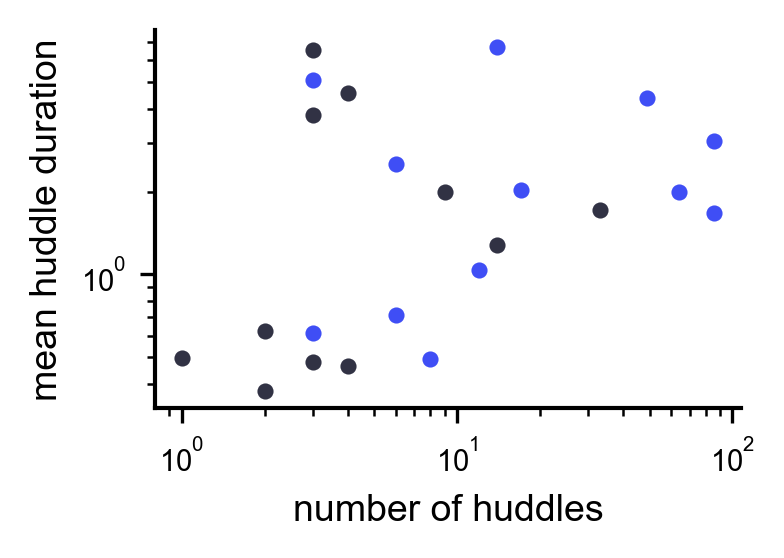

In [65]:
# ----- LOOK AT MEAN DURATION OF HUDDLE VERSUS NUMBER -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()
counts = data.groupby(by=['pair_tag','GT','sex','behavior']).duration.count().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
cpvt = counts.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
blist = [behavs[2]]
sdat = meta.copy()
sdat['duration'] = pvt.loc[:,blist].sum(axis=1)
cdat = meta.copy()
cdat['counts'] = cpvt.loc[:,blist].sum(axis=1)

dat = sdat.copy()
dat['counts'] = cdat['counts']
dat = dat[dat['sex']=='M']
dat['mean_dur'] = dat['duration']/dat['counts']

# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

wt = dat[dat['GT']=='WT'].copy().reset_index(drop=True)
ht = dat[dat['GT']=='Het'].copy().reset_index(drop=True)

# scatter plots
ax.scatter(wt.counts,wt.mean_dur,s=dotsz,c=[mcols[0]],edgecolors='k',linewidths=dlw)
ax.scatter(ht.counts,ht.mean_dur,s=dotsz,c=[mcols[1]],edgecolors='k',linewidths=dlw)

# manage axis
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect('equal')
ax.set_xlabel('number of huddles')
ax.set_ylabel('mean huddle duration')

Text(0, 0.5, 'mean huddle duration')

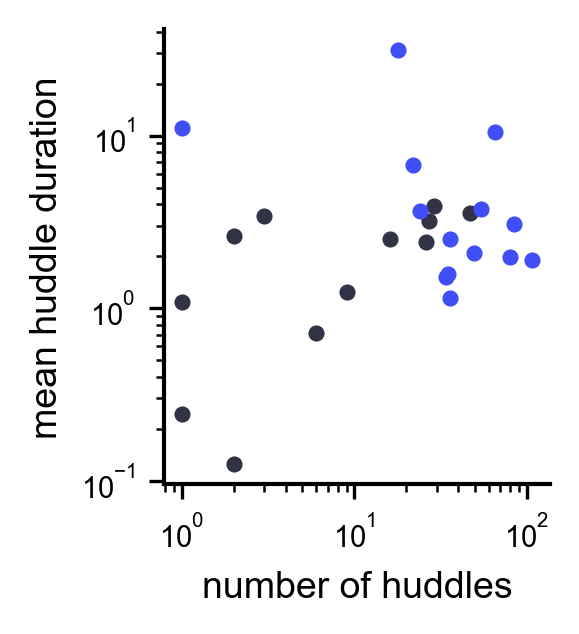

In [66]:
# ----- LOOK AT MEAN DURATION OF HUDDLE VERSUS NUMBER -----
assay = 'introduction'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
sums = data.groupby(by=['pair_tag','GT','sex','behavior']).duration.sum().reset_index()
counts = data.groupby(by=['pair_tag','GT','sex','behavior']).duration.count().reset_index()
pvt = sums.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
cpvt = counts.pivot(index=['pair_tag','GT','sex'],columns='behavior',values='duration').fillna(0).reset_index()
meta = pvt.loc[:,meta].copy()

sexes = ['female','male']
behavs = ['Investigate','Sniff','Huddle']

# filter to relevant single behavior
blist = [behavs[2]]
sdat = meta.copy()
sdat['duration'] = pvt.loc[:,blist].sum(axis=1)
cdat = meta.copy()
cdat['counts'] = cpvt.loc[:,blist].sum(axis=1)

dat = sdat.copy()
dat['counts'] = cdat['counts']
dat = dat[dat['sex']=='M']
dat['mean_dur'] = dat['duration']/dat['counts']

# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

wt = dat[dat['GT']=='WT'].copy().reset_index(drop=True)
ht = dat[dat['GT']=='Het'].copy().reset_index(drop=True)

# scatter plots
ax.scatter(wt.counts,wt.mean_dur,s=dotsz,c=[mcols[0]],edgecolors='k',linewidths=dlw)
ax.scatter(ht.counts,ht.mean_dur,s=dotsz,c=[mcols[1]],edgecolors='k',linewidths=dlw)

# manage axis
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_aspect('equal')
ax.set_xlabel('number of huddles')
ax.set_ylabel('mean huddle duration')

168
644


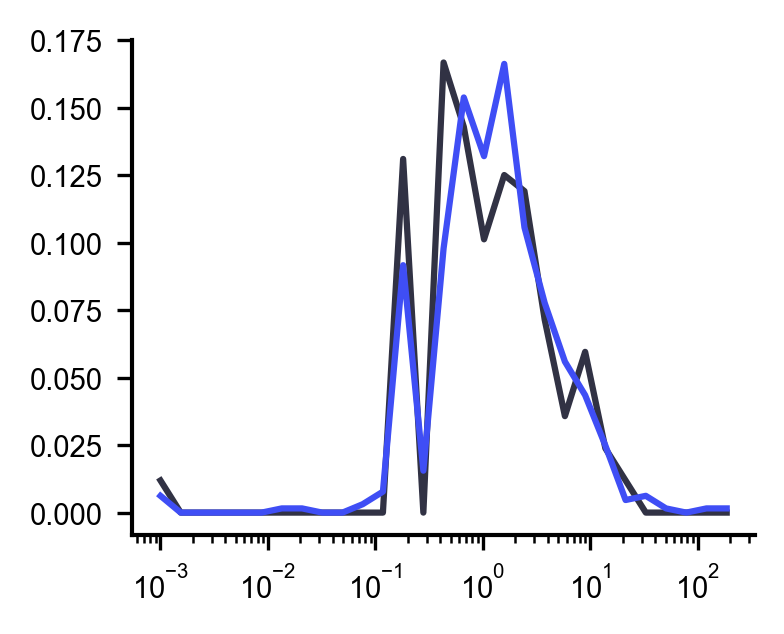

In [92]:
# ----- DISTRIBUTIONS OF HUDDLE LENGTH -----
assay = 'introduction'
assaydur = 1800
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
blist = [behavs[2]]
bdat = data[data['behavior']==blist[0]].copy().reset_index(drop=True)
sdat = bdat[bdat['sex']=='M'].copy().reset_index(drop=True)
sdat = sdat[sdat.duration>0].copy().reset_index(drop=True)
minval = np.min(sdat.duration)
maxval = np.max(sdat.duration)
bins = np.logspace(np.log10(minval),np.log10(maxval),30)
gts = ['WT','Het']
hists = []
for gt in gts:
    thist = np.histogram(sdat[sdat.GT==gt]['duration'],bins=bins)
    hists.append(thist[0])    


# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

ax.plot(bins[0:-1],hists[0]/np.sum(hists[0]),color=mcols[0])
ax.plot(bins[0:-1],hists[1]/np.sum(hists[1]),color=mcols[1])
ax.set_xscale('log')
print(np.sum(hists[0]))
print(np.sum(hists[1]))

78
353


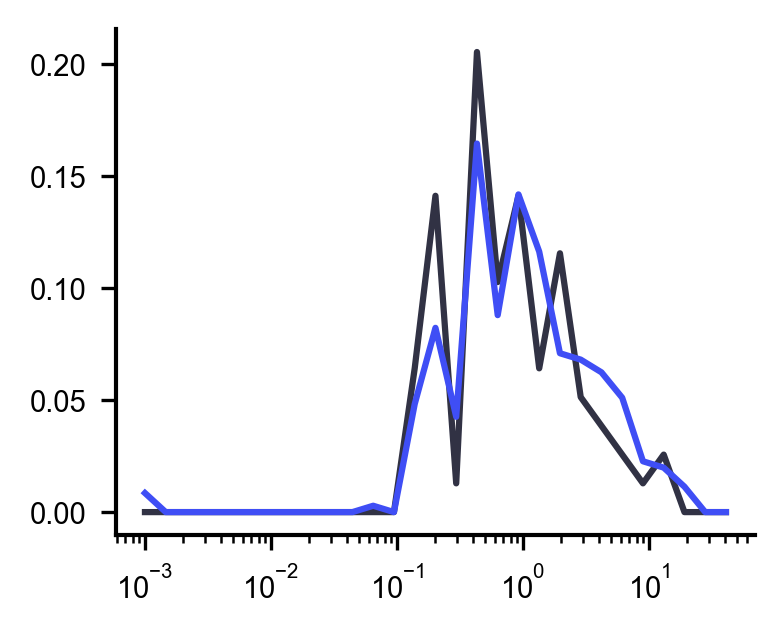

In [91]:
# ----- DISTRIBUTIONS OF HUDDLE LENGTH -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
blist = [behavs[2]]
bdat = data[data['behavior']==blist[0]].copy().reset_index(drop=True)
sdat = bdat[bdat['sex']=='M'].copy().reset_index(drop=True)
sdat = sdat[sdat.duration>0].copy().reset_index(drop=True)
minval = np.min(sdat.duration)
maxval = np.max(sdat.duration)
bins = np.logspace(np.log10(minval),np.log10(maxval),30)
gts = ['WT','Het']
hists = []
for gt in gts:
    thist = np.histogram(sdat[sdat.GT==gt]['duration'],bins=bins)
    hists.append(thist[0])    


# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

ax.plot(bins[0:-1],hists[0]/np.sum(hists[0]),color=mcols[0])
ax.plot(bins[0:-1],hists[1]/np.sum(hists[1]),color=mcols[1])
ax.set_xscale('log')

print(np.sum(hists[0]))
print(np.sum(hists[1]))

In [ ]:
# ----- DISTRIBUTIONS OF HUDDLE LENGTH -----
assay = 'aggression'
assaydur = 1200
meta = ['sex','GT','pair_tag']
data = data_orig[data_orig.assay==assay].copy().reset_index(drop=True)
blist = [behavs[2]]
bdat = data[data['behavior']==blist[0]].copy().reset_index(drop=True)
sdat = bdat[bdat['sex']=='M'].copy().reset_index(drop=True)
sdat = sdat[sdat.duration>0].copy().reset_index(drop=True)
minval = np.min(sdat.duration)
maxval = np.max(sdat.duration)
bins = np.logspace(np.log10(minval),np.log10(maxval),30)
gts = ['WT','Het']
hists = []
for gt in gts:
    thist = np.histogram(sdat[sdat.GT==gt]['duration'],bins=bins)
    hists.append(thist[0])    


# set up figure
figsz = (2.5,2) # total size of figure
fig, ax = plt.subplots(figsize=figsz)

ax.plot(bins[0:-1],hists[0]/np.sum(hists[0]),color=mcols[0])
ax.plot(bins[0:-1],hists[1]/np.sum(hists[1]),color=mcols[1])
ax.set_xscale('log')

print(np.sum(hists[0]))
print(np.sum(hists[1]))

In [82]:
hists

[array([ 2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 22,  0, 28, 24, 17,
        21, 20, 12,  6, 10,  4,  2,  0,  0,  0,  0,  0]),
 array([  4,   0,   0,   0,   0,   0,   1,   1,   0,   0,   2,   5,  59,
         10,  63,  99,  85, 107,  68,  50,  36,  28,  16,   3,   4,   1,
          0,   1,   1])]

In [ ]:
# ----- COMPARISONS -----

# X compare amount of time investigating between intro and aggression, WT vs WT and het vs het
# X compare amount of time huddling between intro and reunion, WT vs WT and het vs het
# plot time investigating vs time huddling in aggression
# plot number investigating vs number huddles in aggression
# repeat for intros?
# transition probabilities of sniffs to huddles for GT x intro, reunion, aggression
# compare durations of huddles preceded by sniff or other
# proportion of sniffs to each other behavior
# proportion of huddles preceded by each other behavior
# time budget clustering